# Measurement x=15, y=0, z=0

### TODO

- Why is the potential probe measurement is so off?

### Imports

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from python_utils.utils import load_object

from python_utils.time_series_extraction import extract_timeseries_data_by_coordinates_and_column
from python_utils.time_series_extraction import find_matching_row_index_from_timeseries
from python_utils.time_series_extraction import extract_time_series_values

### General Args

In [3]:
slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
y_coord = 0.01842125  # Closest to 0.
z_coord = 0.01842125
label = 'vx'  # y, z, vx, vy, vz, jx, jy, jz, P, F=Phi
B_z = 300

### Load Data

In [4]:
pkl_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")

In [5]:
loaded_data = load_object(pkl_path)
timeseries = loaded_data['timeseries']
labels = loaded_data['labels']

print("N =", len(timeseries))
first_snapshot = timeseries[0]
n_x_y, n_v = first_snapshot.shape
n_y = n_z = np.sqrt(n_x_y)
print(f"n_y = {n_y}, n_z = {n_z}, n_v = {n_v}")
print("Labels:")
print(labels)
print("Example Data:")
print(first_snapshot[0:5, 0:3])

Object successfully loaded from c:\Users\hydro\Documents\phd\nuclear_fusion_cooling\data\4pi_re1000_ha300.360_ch28.p1\SliceYZ_x0015\pkl\sliceYZ_x0015_fld.pkl
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 10
Labels:
['y', 'z', 'vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Example Data:
[[-1.        -1.         0.       ]
 [-0.9872207 -1.         0.       ]
 [-0.9667644 -1.         0.       ]
 [-0.9389384 -1.         0.       ]
 [-0.9042407 -1.         0.       ]]


### Plot $v_x$

 x = streamwise

In [6]:
column_index = labels.index(label)
v_x_center = extract_timeseries_data_by_coordinates_and_column(
    arrays=timeseries,
    column_indices=column_index,
    y_coord=y_coord,
    z_coord=z_coord,
    )

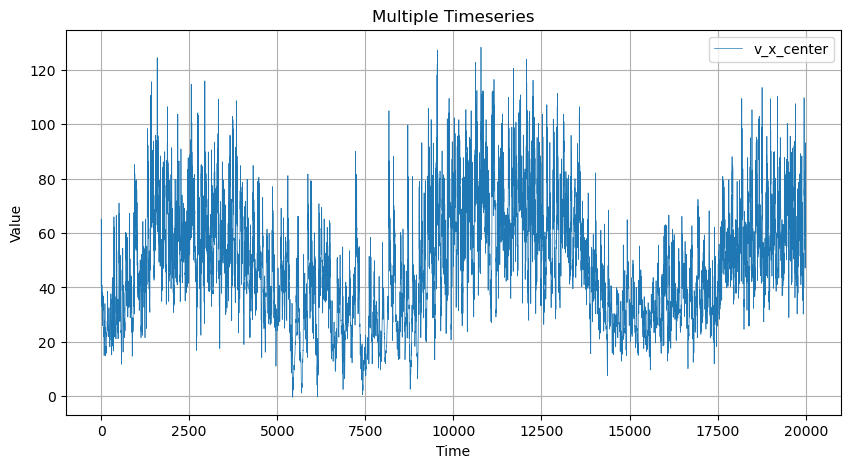

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_timeseries(
        data_list,
        *,
        titles=None,
        xlabel='Time',
        ylabel='Value',
        linewidth=1,
    ):
    # Check if data_list is a single 1D array or list
    if not isinstance(data_list, list):
        data_list = [data_list]  # Wrap in a list if it's not already
    
    # Create an array for the x-axis (time)
    time = np.arange(len(data_list[0]))  # Assuming all data series have the same length
    
    # Create a figure for plotting
    plt.figure(figsize=(10, 5))
    
    # Plot each time series in the provided list
    for i, data in enumerate(data_list):
        title = titles[i] if titles is not None else f"Timeseries {i+1}"
        plt.plot(time, data, linewidth=linewidth, label=title)
    
    plt.title('Multiple Timeseries')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.legend()  # Show legend to identify different timeseries
    plt.show()

plot_timeseries(
    v_x_center,
    titles=["v_x_center"],
    linewidth=0.5,
    )

## Replicate Potential Probe $v_x$ Measurements

Ohm's Law:

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_z \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\Delta \varphi}{\Delta l_x} \\ \frac{\Delta \varphi}{\Delta l_y} \\ \frac{\Delta \varphi}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y = \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x = \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} = \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

In [8]:
delta_l = 0.1  # y, z domain = [-1, 1]

##### Measurement Coordinates

In [9]:
i_center = find_matching_row_index_from_timeseries(
    timeseries,
    y_coord,
    z_coord,
    return_closest=True,
    )
print(f"Center: y = {timeseries[0][i_center][0]}, z = {timeseries[0][i_center][1]}")

y_1 = y_coord - delta_l / 2
i_y_1 = find_matching_row_index_from_timeseries(
    timeseries,
    y_1,
    z_coord,
    return_closest=True,
    )
print(f"y_1 Coordinates: y = {timeseries[0][i_y_1][0]}, z = {timeseries[0][i_y_1][1]}")
print(f"Difference to center: delta_y_1 = {timeseries[0][i_center][0] - timeseries[0][i_y_1][0]}, delta_z_1 = {timeseries[0][i_center][1] - timeseries[0][i_y_1][1]}")

y_2 = y_coord + delta_l / 2
i_y_2 = find_matching_row_index_from_timeseries(
    timeseries,
    y_2,
    z_coord,
    return_closest=True,
    )
print(f"y_2 Coordinates: y = {timeseries[0][i_y_2][0]}, z = {timeseries[0][i_y_2][1]}")
print(f"Difference to center: delta_y_2 = {timeseries[0][i_y_2][0] - timeseries[0][i_center][0]}, delta_z_2 = {timeseries[0][i_y_2][1] - timeseries[0][i_center][1]}")
delta_y = timeseries[0][i_y_2][0] - timeseries[0][i_y_1][0]
delta_z = timeseries[0][i_y_2][1] - timeseries[0][i_y_1][1]
print(f"Difference between y_1 to y_2: delta_y = {delta_y}, delta_z = {delta_z}")
print(f"Index Difference between i_y_1 to i_y_2: delta_i_y = {i_y_2 - i_y_1}, between i_y_2 and i_center = {i_y_2 - i_center}, between i_center and i_y_1 = {i_y_2 - i_center}")

Center: y = 0.01842125, z = 0.01842125
y_1 Coordinates: y = -0.01842125, z = 0.01842125
Difference to center: delta_y_1 = 0.0368425, delta_z_1 = 0.0
y_2 Coordinates: y = 0.05560156, z = 0.01842125
Difference to center: delta_y_2 = 0.03718031, delta_z_2 = 0.0
Difference between y_1 to y_2: delta_y = 0.07402281, delta_z = 0.0
Index Difference between i_y_1 to i_y_2: delta_i_y = 2, between i_y_2 and i_center = 1, between i_center and i_y_1 = 1


##### Acquire all variables

In [15]:
phi_y_1 = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=9,
    row_index=i_y_1,
    )
phi_y_2 = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=9,
    row_index=i_y_2,
    )
j_y_center = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=6,
    row_index=i_center,
    )

delta_phi = phi_y_2 - phi_y_1
partial_phi = delta_phi / delta_y

##### Calculate $v_x$ Potential Probe Estimation

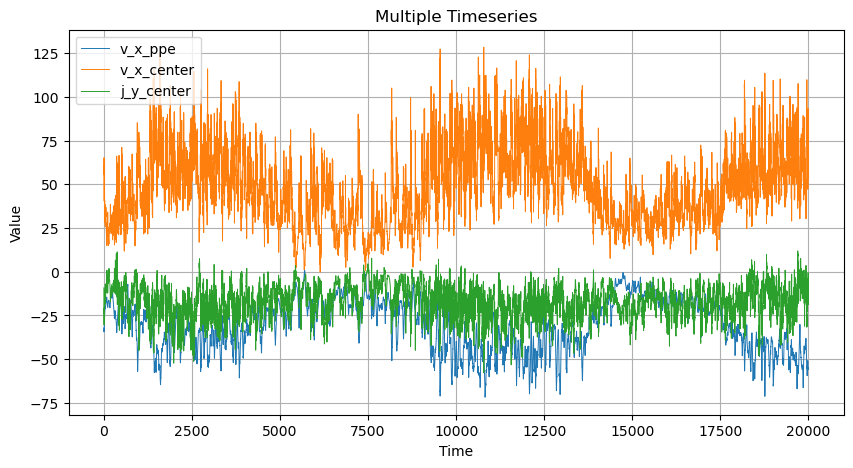

In [17]:
v_x_ppe = partial_phi / B_z
plot_timeseries(
    [
        # v_x_ppe,
        partial_phi,
        v_x_center,
        j_y_center,
        ],
    titles=[
        "v_x_ppe",
        "v_x_center",
        "j_y_center",
        ],
    linewidth=0.7,
    )

##### Calculate Sigma

mean(sigma) = 0.0012145438082188428


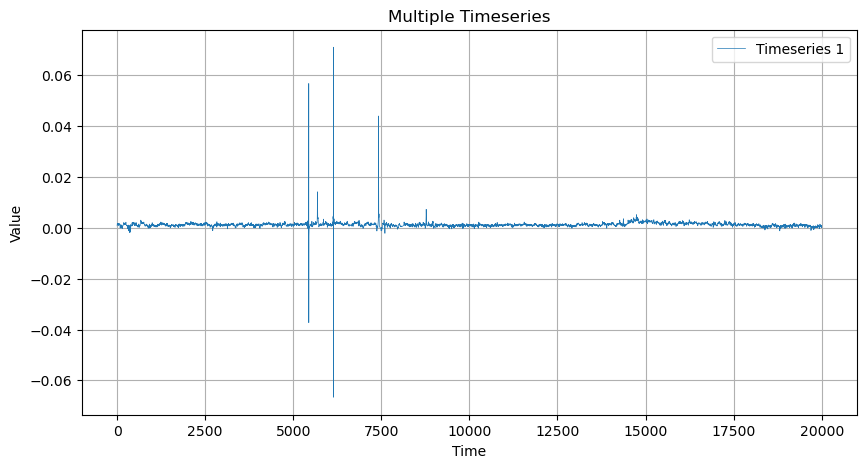

In [12]:
sigma = np.divide(
    j_y_center,
    partial_phi - v_x_center * B_z,
    )

print(f"mean(sigma) = {np.mean(sigma)}")
plot_timeseries(
    sigma,
    linewidth=0.5,
    )